In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_excel(next(iter(uploaded)))
df.head()


Saving Dataset.xlsx to Dataset.xlsx


,Year,January,February,March,April,May,June,July,August,September,October,November,December,Type
0,2021,4207,4000,4431,4395,4249,4157,4918,4569,4811,4177,3887,3710,Injuries
1,2022,3097,2771,3981,4717,5291,4987,4949,5144,5285,5686,5021,5062,Injuries
2,2023,5396,4690,5798,6163,6054,6001,6103,6089,6201,6723,6156,5642,Injuries
3,2024,5989,5241,6478,6724,6097,6063,6392,6856,6722,7155,6245,6400,Injuries
4,2025,6332,5811,7290,6674,6808,7318,6851,7598,8117,8245,7162,6347,Injuries


In [3]:
print(df.columns)
print(df.head())


Index(['Year', 'January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December', 'Type'],
      dtype='object')
   Year  January  February  March  April   May  June  July  August  September  \
0  2021     4207      4000   4431   4395  4249  4157  4918    4569       4811   
1  2022     3097      2771   3981   4717  5291  4987  4949    5144       5285   
2  2023     5396      4690   5798   6163  6054  6001  6103    6089       6201   
3  2024     5989      5241   6478   6724  6097  6063  6392    6856       6722   
4  2025     6332      5811   7290   6674  6808  7318  6851    7598       8117   

   October  November  December      Type  
0     4177      3887      3710  Injuries  
1     5686      5021      5062  Injuries  
2     6723      6156      5642  Injuries  
3     7155      6245      6400  Injuries  
4     8245      7162      6347  Injuries  


In [4]:
import pandas as pd
import numpy as np

months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Convert monthly columns into rows
long_df = df.melt(
    id_vars=["Year", "Type"],
    value_vars=months,
    var_name="Month",
    value_name="Value"
)

# Create a proper date
long_df["Date"] = pd.to_datetime(
    long_df["Year"].astype(str) + "-" + long_df["Month"] + "-01"
)

# Sort the data
long_df = long_df.sort_values(["Type", "Date"])

print(long_df.head(15))


     Year   Type      Month  Value       Date
5    2021  Death    January    468 2021-01-01
15   2021  Death   February    485 2021-02-01
25   2021  Death      March    565 2021-03-01
35   2021  Death      April    613 2021-04-01
45   2021  Death        May    680 2021-05-01
55   2021  Death       June    626 2021-06-01
65   2021  Death       July    674 2021-07-01
75   2021  Death     August    668 2021-08-01
85   2021  Death  September    652 2021-09-01
95   2021  Death    October    629 2021-10-01
105  2021  Death   November    604 2021-11-01
115  2021  Death   December    662 2021-12-01
6    2022  Death    January    571 2022-01-01
16   2022  Death   February    466 2022-02-01
26   2022  Death      March    596 2022-03-01


In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecasts = {}

for data_type in ["Injuries", "Death"]:

    # Use only 2021-2024
    train = long_df[
        (long_df["Type"] == data_type) &
        (long_df["Date"] < "2025-01-01")
    ].copy()

    train = train.set_index("Date")["Value"]

    # Holt-Winters model
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    )

    fit = model.fit()

    # Forecast 12 months
    forecasts[data_type] = fit.forecast(12)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [6]:
forecast_2025 = pd.DataFrame(forecasts)

forecast_2025.index.name = "Date"

print(forecast_2025.round(0))


            Injuries  Death
Date                       
2025-01-01    6337.0  358.0
2025-02-01    5840.0  323.0
2025-03-01    6836.0  391.0
2025-04-01    7163.0  462.0
2025-05-01    7086.0  422.0
2025-06-01    6966.0  412.0
2025-07-01    7255.0  455.0
2025-08-01    7330.0  461.0
2025-09-01    7420.0  418.0
2025-10-01    7601.0  427.0
2025-11-01    6993.0  371.0
2025-12-01    6869.0  390.0


In [7]:
actual_2025 = long_df[
    long_df["Year"] == 2025
].pivot(
    index="Date",
    columns="Type",
    values="Value"
)

print(actual_2025)


Type        Death  Injuries
Date                       
2025-01-01    407      6332
2025-02-01    423      5811
2025-03-01    583      7290
2025-04-01    502      6674
2025-05-01    466      6808
2025-06-01    483      7318
2025-07-01    407      6851
2025-08-01    482      7598
2025-09-01    509      8117
2025-10-01    575      8245
2025-11-01    504      7162
2025-12-01    488      6347


In [8]:
comparison_ets = pd.DataFrame({
    "Actual_Injuries": actual_2025["Injuries"],
    "ETS_Injuries": forecast_2025["Injuries"],
    "Actual_Death": actual_2025["Death"],
    "ETS_Death": forecast_2025["Death"]
})

print(comparison_ets.round(0))


            Actual_Injuries  ETS_Injuries  Actual_Death  ETS_Death
Date                                                              
2025-01-01             6332        6337.0           407      358.0
2025-02-01             5811        5840.0           423      323.0
2025-03-01             7290        6836.0           583      391.0
2025-04-01             6674        7163.0           502      462.0
2025-05-01             6808        7086.0           466      422.0
2025-06-01             7318        6966.0           483      412.0
2025-07-01             6851        7255.0           407      455.0
2025-08-01             7598        7330.0           482      461.0
2025-09-01             8117        7420.0           509      418.0
2025-10-01             8245        7601.0           575      427.0
2025-11-01             7162        6993.0           504      371.0
2025-12-01             6347        6869.0           488      390.0


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def calculate_metrics(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    accuracy = 100 - mape

    return mae, rmse, mape, accuracy


# Injuries
mae_i, rmse_i, mape_i, accuracy_i = calculate_metrics(
    comparison_ets["Actual_Injuries"],
    comparison_ets["ETS_Injuries"]
)

# Death
mae_d, rmse_d, mape_d, accuracy_d = calculate_metrics(
    comparison_ets["Actual_Death"],
    comparison_ets["ETS_Death"]
)

print("===== ETS - INJURIES =====")
print("MAE      :", round(mae_i, 2))
print("RMSE     :", round(rmse_i, 2))
print("MAPE     :", round(mape_i, 2), "%")
print("Accuracy :", round(accuracy_i, 2), "%")

print("\n===== ETS - DEATH =====")
print("MAE      :", round(mae_d, 2))
print("RMSE     :", round(rmse_d, 2))
print("MAPE     :", round(mape_d, 2), "%")
print("Accuracy :", round(accuracy_d, 2), "%")

===== ETS - INJURIES =====
MAE      : 359.46
RMSE     : 416.94
MAPE     : 4.96 %
Accuracy : 95.04 %

===== ETS - DEATH =====
MAE      : 86.35
RMSE     : 99.26
MAPE     : 17.27 %
Accuracy : 82.73 %


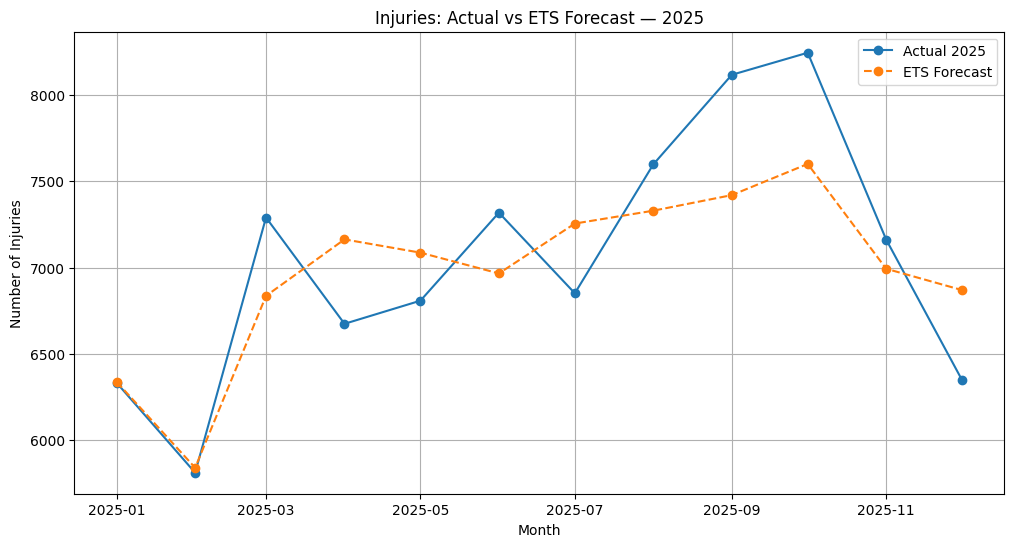

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    comparison_ets.index,
    comparison_ets["Actual_Injuries"],
    marker="o",
    label="Actual 2025"
)

plt.plot(
    comparison_ets.index,
    comparison_ets["ETS_Injuries"],
    marker="o",
    linestyle="--",
    label="ETS Forecast"
)

plt.title("Injuries: Actual vs ETS Forecast — 2025")
plt.xlabel("Month")
plt.ylabel("Number of Injuries")
plt.legend()
plt.grid(True)
plt.show()


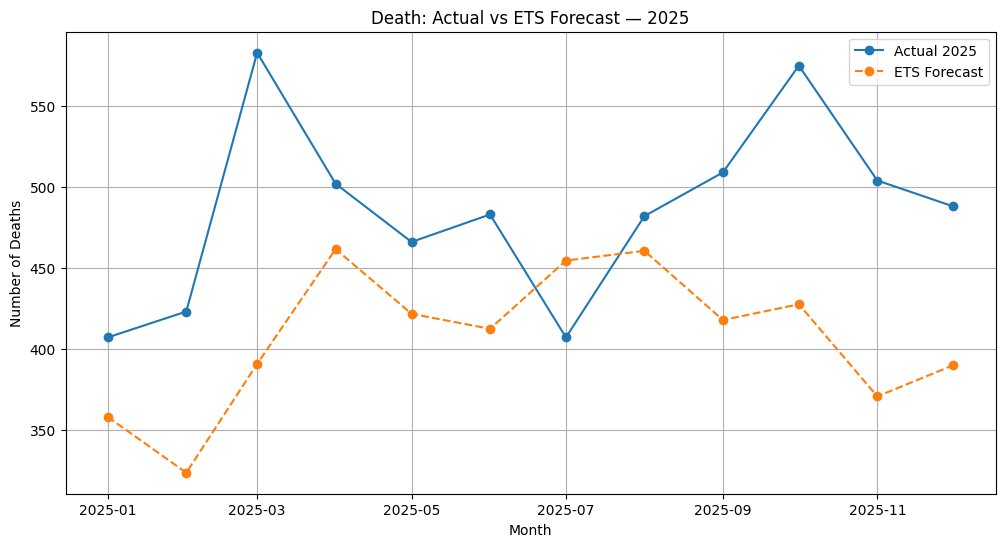

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_ets.index,
    comparison_ets["Actual_Death"],
    marker="o",
    label="Actual 2025"
)

plt.plot(
    comparison_ets.index,
    comparison_ets["ETS_Death"],
    marker="o",
    linestyle="--",
    label="ETS Forecast"
)

plt.title("Death: Actual vs ETS Forecast — 2025")
plt.xlabel("Month")
plt.ylabel("Number of Deaths")
plt.legend()
plt.grid(True)
plt.show()
